# Model Calibration

## Overview

A model is well-calibrated if its predicted probabilities match observed frequencies. A model that says "80% probability" for 100 events should see approximately 80 of them occur.

**Why calibration matters:**
- Decision-making requires reliable probabilities, not just rankings
- ROC-AUC measures discrimination (ranking), not calibration
- A model with AUC 0.90 can be badly miscalibrated

**Calibration tools:**

| Tool | Measures |
|---|---|
| Calibration curve (reliability diagram) | Predicted vs observed probability |
| Brier score | Mean squared error of probabilities (lower = better) |
| Expected Calibration Error (ECE) | Weighted mean calibration gap |
| Calibration methods | Platt scaling, isotonic regression |

---

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)
n = 800
elevation = rng.uniform(50, 400, n)
nitrate   = rng.gamma(2, 2, n)
richness  = 25 - 0.03*elevation - 0.7*nitrate + rng.normal(0, 3, n)
log_odds  = -2 + 0.003*elevation - 0.1*nitrate + 0.08*richness
prob      = 1/(1+np.exp(-log_odds))
y         = rng.binomial(1, prob, n)
X         = np.column_stack([elevation, nitrate, richness])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3,
                                            stratify=y, random_state=42)
print(f"Train={len(X_tr)}, Test={len(X_te)}, prevalence={y.mean():.2f}")

Train=560, Test=240, prevalence=0.37


---
## Calibration Curves

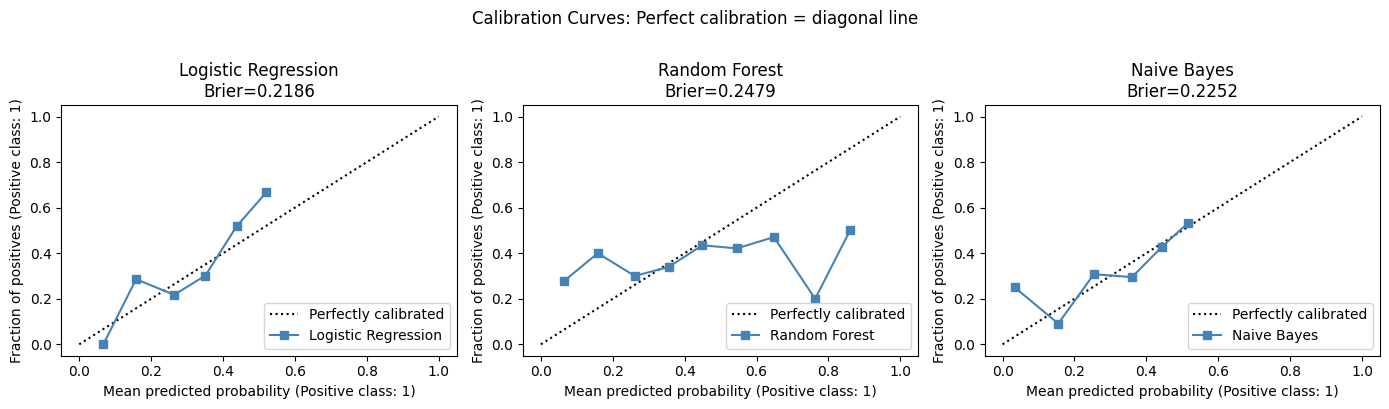

In [8]:
classifiers = {
    "Logistic Regression": Pipeline([("sc", StandardScaler()),
        ("clf", LogisticRegression(random_state=42, max_iter=500))]),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Naive Bayes":         GaussianNB(),
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, clf) in zip(axes, classifiers.items()):
    clf.fit(X_tr, y_tr)
    prob_pos = clf.predict_proba(X_te)[:,1]
    CalibrationDisplay.from_predictions(y_te, prob_pos, n_bins=10, ax=ax,
                                         name=name, color="steelblue")
    bs = brier_score_loss(y_te, prob_pos)
    ax.set_title(f"{name}\nBrier={bs:.4f}")
plt.suptitle("Calibration Curves: Perfect calibration = diagonal line", y=1.01)
plt.tight_layout(); plt.show()

---
## Platt Scaling and Isotonic Calibration

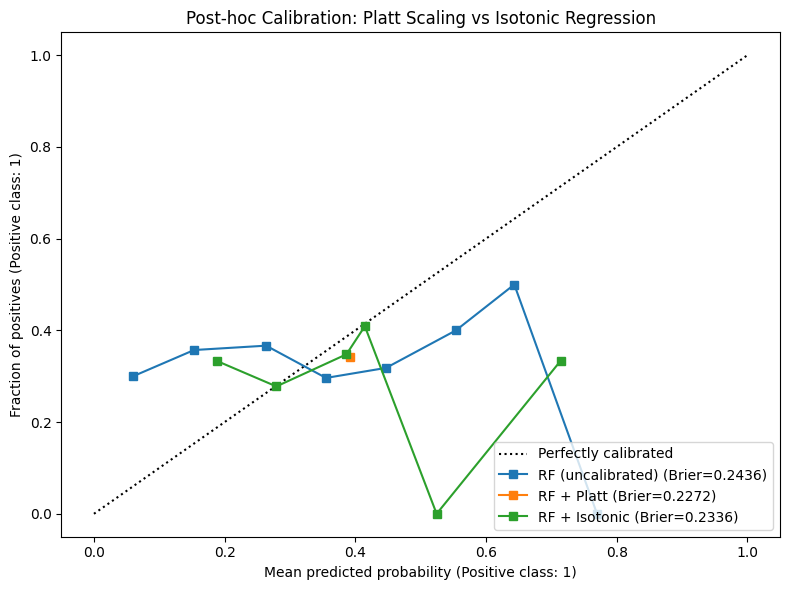

In [9]:
from sklearn.base import clone
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_tr, y_tr)
# Calibrate using a fresh clone as the base_estimator and an integer cv >= 2
rf_platt    = CalibratedClassifierCV(estimator=clone(rf), method="sigmoid",  cv=2)
rf_isotonic = CalibratedClassifierCV(estimator=clone(rf), method="isotonic", cv=2)
# Fit calibrators on a held-out calibration set (first half of test set)
cal_X, cal_y = X_te[:len(X_te)//2], y_te[:len(X_te)//2]
rf_platt.fit(cal_X, cal_y)
rf_isotonic.fit(cal_X, cal_y)
X_eval, y_eval = X_te[len(X_te)//2:], y_te[len(X_te)//2:]
fig, ax = plt.subplots(figsize=(8,6))
for clf, name, color in [
        (rf,          "RF (uncalibrated)", "steelblue"),
        (rf_platt,    "RF + Platt",        "#e74c3c"),
        (rf_isotonic, "RF + Isotonic",     "#4fffb0")]:
    probs = clf.predict_proba(X_eval)[:,1]
    bs = brier_score_loss(y_eval, probs)
    CalibrationDisplay.from_predictions(y_eval, probs, n_bins=10,
                                         ax=ax, name=f"{name} (Brier={bs:.4f})")
ax.set_title("Post-hoc Calibration: Platt Scaling vs Isotonic Regression")
plt.tight_layout(); plt.show()

---
## Expected Calibration Error (ECE)

In [10]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        acc  = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)
    return ece

for clf, name in [(rf, "RF uncalibrated"),
                   (rf_platt, "RF + Platt"),
                   (rf_isotonic, "RF + Isotonic")]:
    probs = clf.predict_proba(X_eval)[:,1]
    ece = expected_calibration_error(y_eval, probs)
    bs  = brier_score_loss(y_eval, probs)
    print(f"{name:25s}: ECE={ece:.4f}, Brier={bs:.4f}")
print("\nECE=0.0 is perfect; ECE>0.05 is poor calibration for most applications")

RF uncalibrated          : ECE=0.1329, Brier=0.2436
RF + Platt               : ECE=0.0503, Brier=0.2272
RF + Isotonic            : ECE=0.0548, Brier=0.2336

ECE=0.0 is perfect; ECE>0.05 is poor calibration for most applications


In [11]:
# Brier skill score: calibration relative to climatological baseline
def brier_skill_score(y_true, y_prob):
    bs_model = brier_score_loss(y_true, y_prob)
    bs_clim  = brier_score_loss(y_true, np.full_like(y_prob, y_true.mean()))
    return 1 - bs_model / bs_clim

print("Brier Skill Scores (higher = better, 1.0 = perfect, 0.0 = climatology):")
clf_list = [
    (Pipeline([("sc",StandardScaler()),("clf",LogisticRegression(max_iter=500,random_state=42))]),
     "Logistic Regression"),
    (RandomForestClassifier(200, random_state=42), "Random Forest"),
    (GaussianNB(), "Naive Bayes"),
]
for clf, name in clf_list:
    clf.fit(X_tr, y_tr)
    probs = clf.predict_proba(X_te)[:,1]
    bss = brier_skill_score(y_te, probs)
    print(f"  {name:25s}: BSS={bss:.4f}")

Brier Skill Scores (higher = better, 1.0 = perfect, 0.0 = climatology):
  Logistic Regression      : BSS=0.0587
  Random Forest            : BSS=-0.0674
  Naive Bayes              : BSS=0.0302


---

## Common Pitfalls

**1. Reporting only AUC and assuming the model is ready for deployment**  
AUC measures discrimination (ranking ability) but not calibration. A model with AUC 0.92 can assign probability 0.95 to events that occur only 40% of the time. Always check calibration before using predicted probabilities in decision-making.

**2. Calibrating on the same data used to fit the model**  
Post-hoc calibration (Platt scaling, isotonic) must be fitted on held-out data — not the training set. Calibrating on training data overfits the calibration function and produces overconfident probabilities.

**3. Using isotonic calibration with small calibration sets**  
Isotonic regression is non-parametric and can overfit aggressively when the calibration set is small (n < 300). Use Platt scaling (sigmoid) for small calibration sets; isotonic calibration requires larger n to be reliable.

**4. Interpreting a flat calibration curve as good calibration**  
A flat curve (predicted probability near 0.5 for all observations) means the model cannot distinguish between cases — it appears well-calibrated only because it makes no strong predictions. Check both calibration and sharpness (spread of predicted probabilities).

**5. Not re-calibrating after changes to the class prevalence**  
Calibration is tied to the prevalence of the outcome in the data used to fit the model. If the model is deployed in a population with a different prevalence, probabilities will be systematically biased and recalibration is needed.

---
*python_methods_library - Samantha McGarrigle*